신용카드 거래 데이터를 불러와서 전처리된 피처(V1~V28, Time, Amount)와 라벨(Class)로 구성된 데이터셋 사용했음.

PyTorch로 간단한 MLP(다층 퍼셉트론) 모델을 만들어 학습했음.

모델의 기본 성능을 확인하기 위해 ROC 곡선, PR 곡선, 혼동행렬을 시각화했음.

이후 랜덤 마스킹(Random Masking) 을 적용해 입력 피처 일부를 임의로 0으로 가렸음.

마스킹 비율을 0%, 10%, 30%, 50% 로 설정하고 각 비율에서 모델의 AUC와 F1 점수를 비교했음.

마스킹 비율이 높아질수록 AUC와 F1이 점점 감소하는 걸 확인했음.

즉, 입력 데이터의 일부 정보가 사라지면 모델이 거래를 제대로 구분하지 못해 성능이 떨어짐을 확인했음.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, precision_recall_fscore_support
)


In [ ]:
 #1) 구글 드라이브 마운트
# ------------------------
drive.mount("/content/drive")

# 내 드라이브 안의 CSV 경로 지정 (폴더명에 맞게 수정)
path = "/content/drive/MyDrive/정보기/scaled.csv"
print("로드 대상:", path)


Mounted at /content/drive
로드 대상: /content/drive/MyDrive/정보기/scaled.csv


In [ ]:
# 2) CSV 로드 (깨진 행 자동 스킵)
# ------------------------
try:
    df = pd.read_csv(path)
except Exception as e:
    print("[WARN] 기본 파서 실패 → python 엔진으로 재시도 (깨진 행 스킵)")
    df = pd.read_csv(path, engine="python", on_bad_lines="skip")

print("shape:", df.shape)
print("columns:", df.columns.tolist()[:10])
assert "Class" in df.columns, "'Class' 컬럼이 없습니다."

shape: (284807, 31)
columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


In [ ]:
# 3) 데이터 분리
# ------------------------
X = df.drop(columns=["Class"]).values
y = df["Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

In [ ]:
 #4) 단순 MLP 모델
# ------------------------
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# 5) 학습 루프
# ------------------------
for epoch in range(15):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 3 == 0:
        print(f"[Epoch {epoch+1}] Loss: {total_loss/len(train_loader):.4f}")

[Epoch 3] Loss: 0.0036
[Epoch 6] Loss: 0.0031
[Epoch 9] Loss: 0.0026
[Epoch 12] Loss: 0.0021
[Epoch 15] Loss: 0.0018


In [ ]:
# 6) 평가 함수
# ------------------------
@torch.no_grad()
def evaluate(Xt, yt):
    model.eval()
    p = torch.sigmoid(model(Xt.to(device))).cpu().numpy().ravel()
    pred = (p >= 0.5).astype(int)
    auc = roc_auc_score(yt.numpy(), p)
    f1  = f1_score(yt.numpy(), pred)
    return auc, f1

In [ ]:
# 7) 랜덤 마스킹 함수
# ------------------------
def random_mask(X, rate):
    if rate <= 0: return X.copy()
    X_mask = X.copy()
    n, d = X.shape
    k = max(1, int(d * rate))
    rng = np.random.default_rng(42)
    for i in range(n):
        idx = rng.choice(d, size=k, replace=False)
        X_mask[i, idx] = 0.0
    return X_mask

In [ ]:
# 8) 마스킹 비율별 성능 비교
# ------------------------
mask_rates = [0.0, 0.1, 0.3, 0.5]
print("\n=== 랜덤 마스킹 성능 변화 ===")
for r in mask_rates:
    X_masked_t = torch.tensor(random_mask(X_test, r), dtype=torch.float32)
    auc, f1 = evaluate(X_masked_t, y_test_t)
    print(f"Mask {r:.1f} → AUC={auc:.4f}, F1={f1:.4f}")



=== 랜덤 마스킹 성능 변화 ===
Mask 0.0 → AUC=0.9809, F1=0.7905
Mask 0.1 → AUC=0.9596, F1=0.6802
Mask 0.3 → AUC=0.8666, F1=0.4100
Mask 0.5 → AUC=0.6245, F1=0.1339


=== Baseline (No Masking, τ=0.5) ===
AUC = 0.9809
AP  = 0.8350
Precision = 0.7411  Recall = 0.8469  F1 = 0.7905


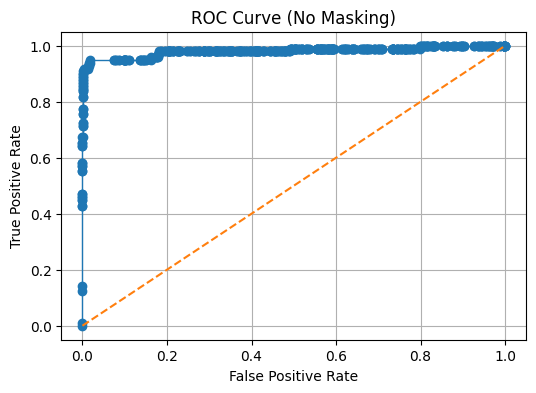

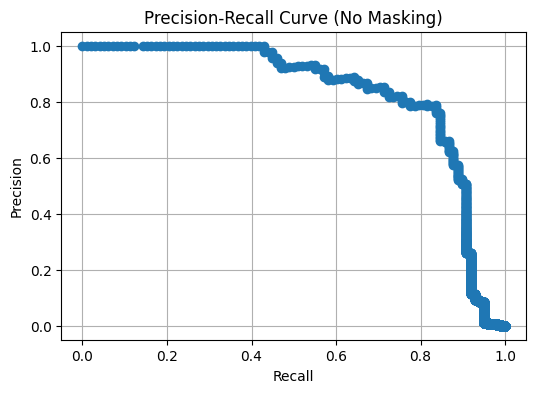

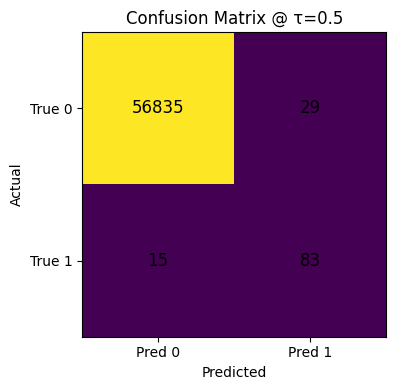


=== Random Masking Impact (Test) ===
 mask_rate      AUC       F1
       0.0 0.980889 0.790476
       0.1 0.959552 0.680203
       0.3 0.866650 0.410000
       0.5 0.624537 0.133891


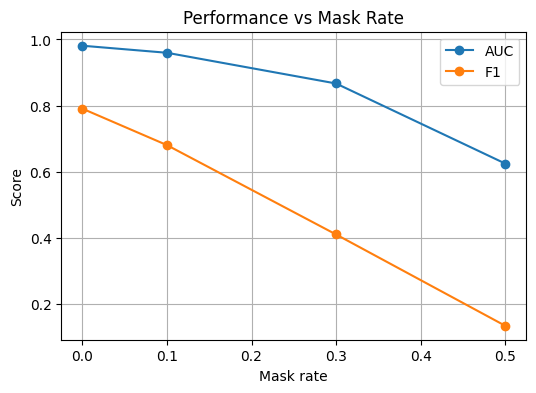

In [ ]:
# 9) 기준 성능(마스킹 없음)
# ----------------------------
with torch.no_grad():
    probs = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32).to(next(model.parameters()).device))).cpu().numpy().ravel()

y_true = y_test_t.numpy().ravel()
pred = (probs >= 0.5).astype(int)

auc  = roc_auc_score(y_true, probs)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
ap   = average_precision_score(y_true, probs)

print("=== Baseline (No Masking, τ=0.5) ===")
print(f"AUC = {auc:.4f}")
print(f"AP  = {ap:.4f}")
print(f"Precision = {prec:.4f}  Recall = {rec:.4f}  F1 = {f1:.4f}")

# ROC 곡선
fpr, tpr, _ = roc_curve(y_true, probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, marker="o", linewidth=1)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve (No Masking)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

# PR 곡선
pr_prec, pr_rec, _ = precision_recall_curve(y_true, probs)
plt.figure(figsize=(6,4))
plt.plot(pr_rec, pr_prec, marker="o", linewidth=1)
plt.title("Precision-Recall Curve (No Masking)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# 혼동행렬(τ=0.5)
cm = confusion_matrix(y_true, pred)
plt.figure(figsize=(4.5,4))
plt.imshow(cm)
plt.title("Confusion Matrix @ τ=0.5")
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ----------------------------
# 10) 마스킹별 성능 비교 (0, 0.1, 0.3, 0.5)
# ----------------------------
mask_rates = [0.0, 0.1, 0.3, 0.5]
records = []
for r in mask_rates:
    X_masked = torch.tensor(random_mask(X_test, r), dtype=torch.float32)
    auc_r, f1_r = evaluate(X_masked, y_test_t)  # evaluate는 AUC/F1 반환(이전 코드 기준)
    records.append([r, auc_r, f1_r])

results_df = pd.DataFrame(records, columns=["mask_rate","AUC","F1"])
results_df = results_df.sort_values("mask_rate").reset_index(drop=True)
print("\n=== Random Masking Impact (Test) ===")
print(results_df.to_string(index=False))

# 선 그래프 (AUC, F1)
plt.figure(figsize=(6,4))
plt.plot(results_df["mask_rate"], results_df["AUC"], marker="o", label="AUC")
plt.plot(results_df["mask_rate"], results_df["F1"],  marker="o", label="F1")
plt.title("Performance vs Mask Rate")
plt.xlabel("Mask rate")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()